covid

import libraries and csv file

In [2]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#import csv file
covid = pd.read_csv("CovidData/Covid Data.csv")

prepare data

In [5]:
# delete duplicate rows
covid.drop_duplicates(inplace=True)

In [6]:
# delete not used columns
covid.drop(columns=['MEDICAL_UNIT','USMER'], inplace =True)

In [7]:
# rename columns
covid.rename(columns=
             {'PATIENT_TYPE':'HOSPITALIZED',
              'DATE_DIED':'DEAD',
              'INMSUPR': 'IMMUNOSUPPRESSED',
              'CLASIFFICATION_FINAL': 'COVID_TEST_RESULT',
              'TOBACCO': "SMOKER",
              'CARDIOVASCULAR': 'CARDIOVASCULAR_DISEASE',
              'RENAL_CHRONIC': 'CHRONIC_KIDNEY_DISEASE',
              'ICU': 'ADMITTED_TO_ICU'}, inplace=True)

In [8]:
# update columns order
covid = covid.loc[:,
                  ['COVID_TEST_RESULT', 
                   'HOSPITALIZED',
                   'INTUBED',
                   'ADMITTED_TO_ICU',
                   'DEAD',
                   'AGE',
                   'SEX',
                   'PREGNANT',
                   'SMOKER',
                   'PNEUMONIA',
                   'COPD',
                   'ASTHMA',
                   'IMMUNOSUPPRESSED',
                   'CARDIOVASCULAR_DISEASE',
                   'HIPERTENSION',
                   'CHRONIC_KIDNEY_DISEASE',
                   'DIABETES',
                   'OBESITY',
                   'OTHER_DISEASE']]

In [9]:
# column "DEAD" dead: 1, alive: 0
covid['DEAD'] = covid['DEAD'].replace({'9999-99-99': 0})
covid['DEAD'] = covid['DEAD'].apply(lambda x: 1 if x != 0 else 0)

In [10]:
# column "SEX" female: 1, male: 0
covid['SEX'] = covid['SEX'].replace({2:0})

In [11]:
# change 2 for 0 ('False'), 97, 98 and 99 for 0
covid[['INTUBED','ADMITTED_TO_ICU','PREGNANT','SMOKER','PNEUMONIA','COPD','ASTHMA','IMMUNOSUPPRESSED',
       'CARDIOVASCULAR_DISEASE','HIPERTENSION','CHRONIC_KIDNEY_DISEASE', 'DIABETES','OBESITY','OTHER_DISEASE']] = covid[[
           'INTUBED','ADMITTED_TO_ICU','PREGNANT','SMOKER','PNEUMONIA','COPD','ASTHMA','IMMUNOSUPPRESSED',
           'CARDIOVASCULAR_DISEASE','HIPERTENSION', 'CHRONIC_KIDNEY_DISEASE','DIABETES','OBESITY','OTHER_DISEASE']].replace({2: 0, 97: 0, 98: 0, 99: 0})

In [12]:
#change column "HOSPITALIZED" to 0,1 format
covid['HOSPITALIZED'] = covid['HOSPITALIZED'].replace({1: 0, 2: 1})

In [13]:
#update column "COVID_TEST_RESULT" to 0,1 format
covid['COVID_TEST_RESULT'] = covid['COVID_TEST_RESULT'].apply(lambda x: 1 if x in [1,2,3] else 0)

In [14]:
#function creating a values for age group
def grouping_age(row) -> str:
    if row['AGE'] < 18:
        val = '-18'
    elif row['AGE'] < 30:
        val = '18-30'
    elif row['AGE'] < 45:
        val = '30-45'
    elif row['AGE'] < 60:
        val = '45-60'
    else:
        val = '60+'
    return val

In [15]:
#create column "AGE_GROUP"
covid["AGE_GROUP"] = covid.apply(grouping_age, axis=1)

In [16]:
#move column "AGE_GROUP" next to "AGE" column
column_to_move = covid.pop('AGE_GROUP')
covid.insert(6, "AGE_GROUP", column_to_move)

In [17]:
#create a table grouped by age and aggregated as sum
grouped_by_age = covid.groupby("AGE_GROUP")
covid_age = grouped_by_age.sum()

In [18]:
covid_age

,COVID_TEST_RESULT,HOSPITALIZED,INTUBED,ADMITTED_TO_ICU,DEAD,AGE,SEX,PREGNANT,SMOKER,PNEUMONIA,COPD,ASTHMA,IMMUNOSUPPRESSED,CARDIOVASCULAR_DISEASE,HIPERTENSION,CHRONIC_KIDNEY_DISEASE,DIABETES,OBESITY,OTHER_DISEASE
AGE_GROUP,,,,,,,,,,,,,,,,,,,
-18,2198,5190,899,930,802,81093,4978,143,239,2535,78,1172,1170,636,299,298,300,916,1695
18-30,6507,6516,951,775,1377,471186,10001,1452,3625,4421,301,2387,1188,831,2559,1297,1792,4837,1880
30-45,19994,19864,3883,2385,7644,1752941,21825,1357,8419,15089,1113,4750,2633,2348,11236,2915,9603,15555,4121
45-60,35475,39947,10370,4772,23014,3618935,30350,52,9509,30365,3026,4637,3403,4489,26773,5062,24899,22238,5335
60+,49114,65127,16192,6521,43128,6521908,39869,16,10833,47320,9551,3090,3896,9607,47138,7532,37162,19782,6549


charts

C:\Users\bartb\AppData\Local\Temp\ipykernel_40300\2512485428.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="AGE_GROUP", y="COVID_TEST_RESULT", estimator="sum", data=covid_age, palette="YlGnBu")


[Text(0.5, 0, 'grupa wiekowa'), Text(0, 0.5, 'ilość z pozytywnym testem')]

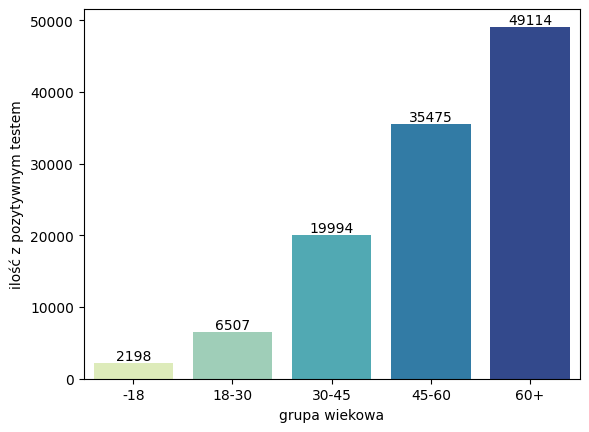

In [19]:
#sum of positive covid test in each age group
ax = sns.barplot(x="AGE_GROUP", y="COVID_TEST_RESULT", estimator="sum", data=covid_age, palette="YlGnBu")
for container in ax.containers:
    ax.bar_label(container)
ax.set(xlabel="grupa wiekowa", ylabel="ilość z pozytywnym testem")

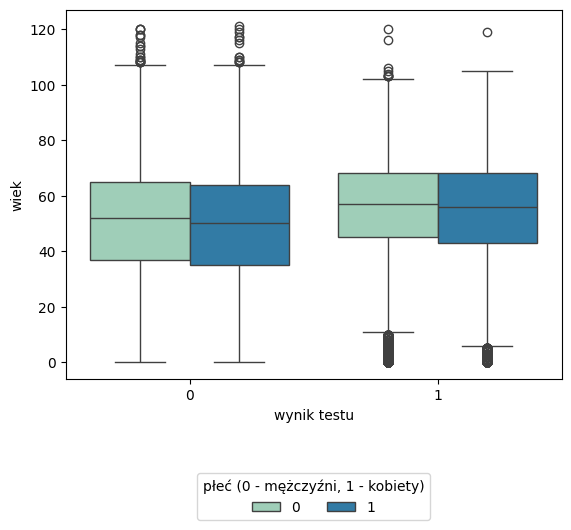

In [20]:
#median and quartiles
ax = sns.boxplot(x="COVID_TEST_RESULT", y="AGE", data=covid, hue="SEX", palette="YlGnBu")
ax.set(xlabel="wynik testu", ylabel="wiek")
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, -0.4), ncol=2, title="płeć (0 - mężczyźni, 1 - kobiety)", frameon=True)

In [21]:
#create a table with column's values 0,1
covid_sick = covid[['COVID_TEST_RESULT','HOSPITALIZED','INTUBED','ADMITTED_TO_ICU','DEAD','AGE','SEX','PREGNANT','SMOKER','PNEUMONIA','COPD','ASTHMA','IMMUNOSUPPRESSED','CARDIOVASCULAR_DISEASE','HIPERTENSION','CHRONIC_KIDNEY_DISEASE', 'DIABETES','OBESITY','OTHER_DISEASE']]

In [22]:
#only positive covid patients
covid_sick = covid_sick.loc[(covid_sick['COVID_TEST_RESULT'] == 1)]

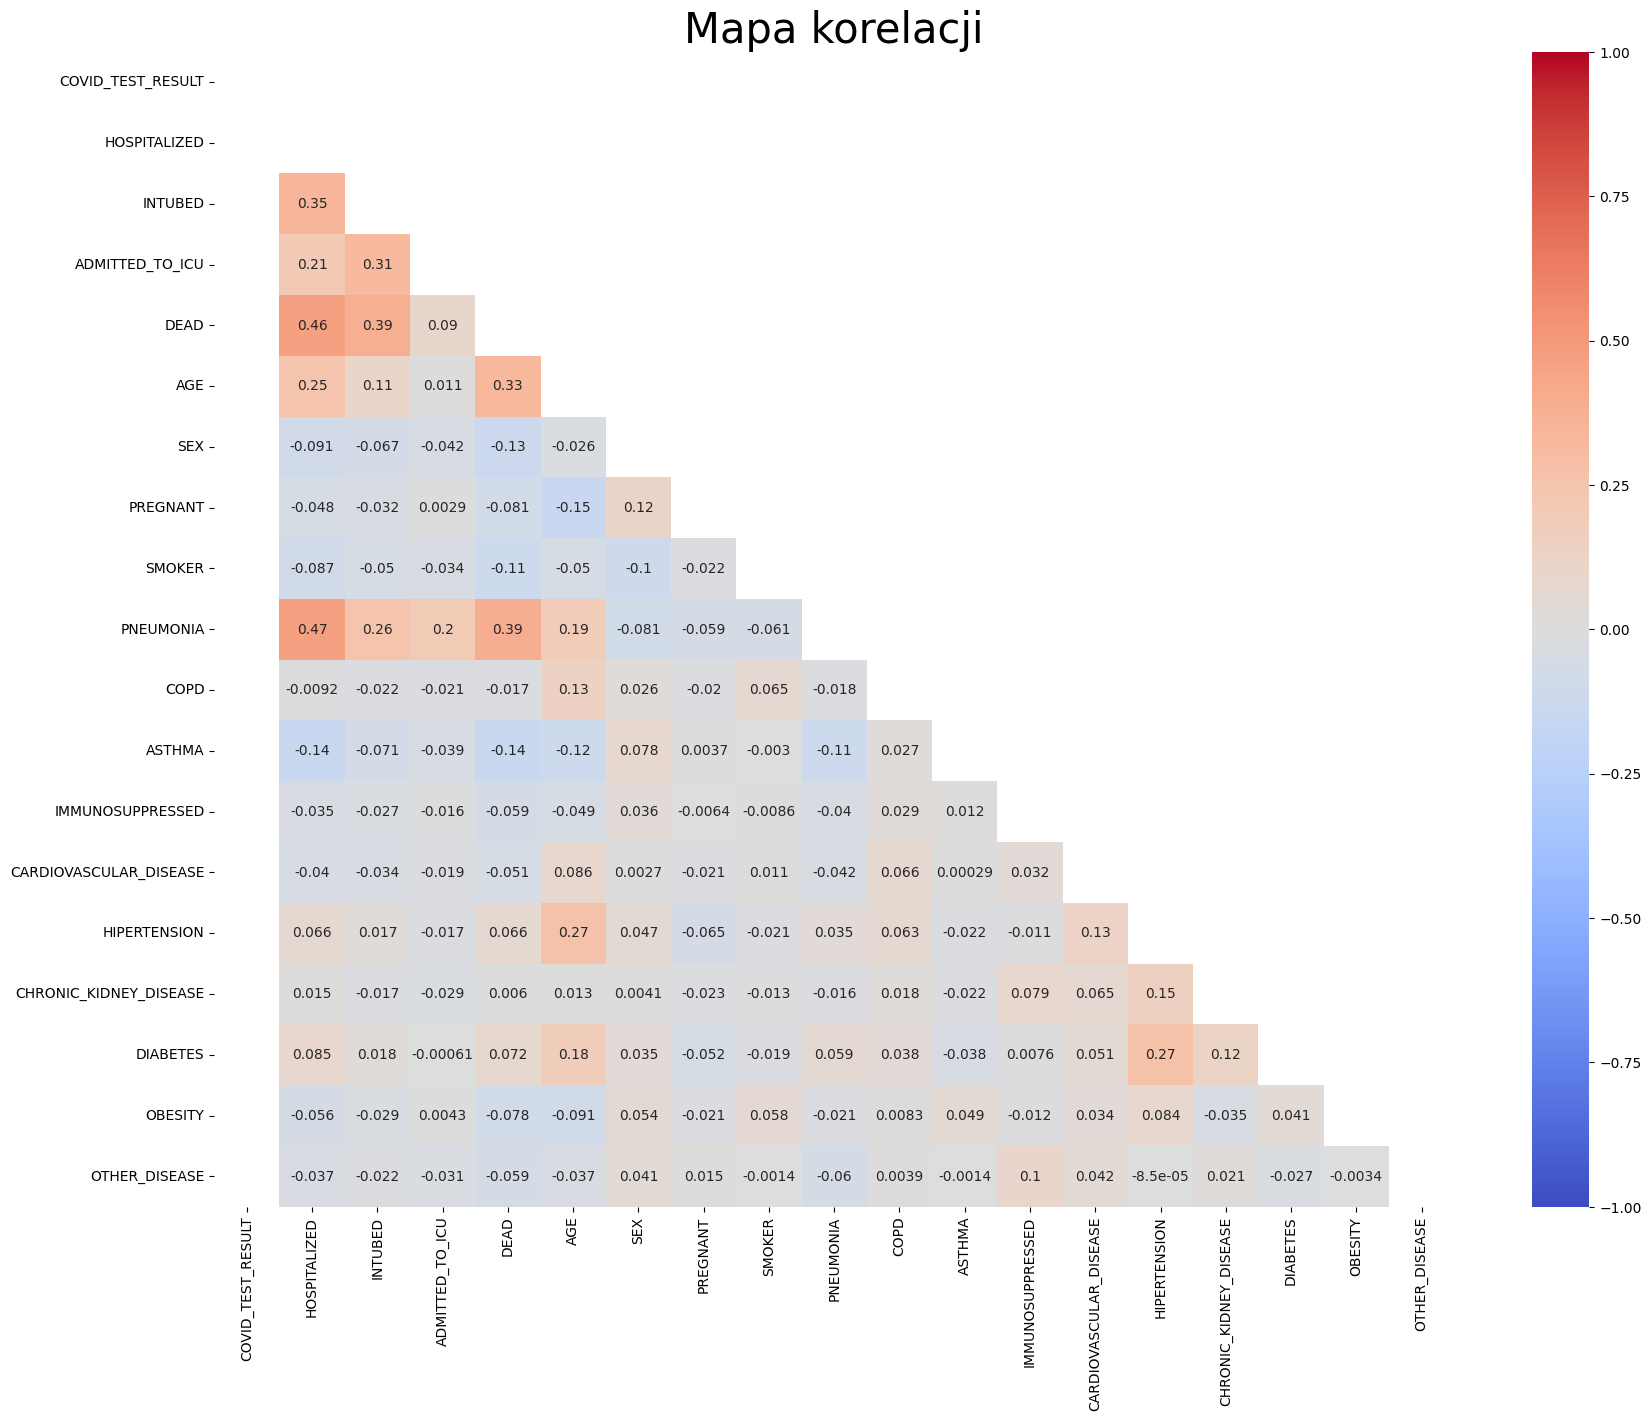

In [23]:
#heatmap with correlations
fig, ax = plt.subplots(figsize=(20, 15))
#create a mask to hide a duplicated half of the map
mask=np.triu(np.ones_like(covid_sick.corr()))
sns.heatmap(covid_sick.corr(), mask = mask, annot = True, cmap = "coolwarm", vmin = -1, vmax = 1)
plt.title('Mapa korelacji', color = 'black', fontsize = 30)
plt.show()

In [24]:
#create a list of conditions to be correlated with death
conditions = ['INTUBED','ADMITTED_TO_ICU', 'AGE','SEX','PREGNANT','SMOKER','PNEUMONIA','COPD','ASTHMA','IMMUNOSUPPRESSED','CARDIOVASCULAR_DISEASE','HIPERTENSION','CHRONIC_KIDNEY_DISEASE', 'DIABETES','OBESITY','OTHER_DISEASE']

In [25]:
#correlating in for loop and creating a dictionary
death_corrs = {}
for condition in conditions:
    corr = round(covid_sick[condition].corr(covid_sick["DEAD"]),3)
    death_corrs[condition] = corr

In [26]:
death_corrs

{'INTUBED': 0.39,
 'ADMITTED_TO_ICU': 0.09,
 'AGE': 0.33,
 'SEX': -0.129,
 'PREGNANT': -0.081,
 'SMOKER': -0.113,
 'PNEUMONIA': 0.392,
 'COPD': -0.017,
 'ASTHMA': -0.139,
 'IMMUNOSUPPRESSED': -0.059,
 'CARDIOVASCULAR_DISEASE': -0.051,
 'HIPERTENSION': 0.066,
 'CHRONIC_KIDNEY_DISEASE': 0.006,
 'DIABETES': 0.072,
 'OBESITY': -0.078,
 'OTHER_DISEASE': -0.059}

In [27]:
#list with sorted correlations
death_corrs = sorted(death_corrs.items(), key=lambda x: x[1], reverse=True)

In [28]:
death_corrs

[('PNEUMONIA', 0.392),
 ('INTUBED', 0.39),
 ('AGE', 0.33),
 ('ADMITTED_TO_ICU', 0.09),
 ('DIABETES', 0.072),
 ('HIPERTENSION', 0.066),
 ('CHRONIC_KIDNEY_DISEASE', 0.006),
 ('COPD', -0.017),
 ('CARDIOVASCULAR_DISEASE', -0.051),
 ('IMMUNOSUPPRESSED', -0.059),
 ('OTHER_DISEASE', -0.059),
 ('OBESITY', -0.078),
 ('PREGNANT', -0.081),
 ('SMOKER', -0.113),
 ('SEX', -0.129),
 ('ASTHMA', -0.139)]

In [30]:
covid_sick["PNEUMONIA_AND_INTUBED"] = (covid_sick["PNEUMONIA"]) & (covid_sick["INTUBED"])

In [32]:
covid_sick.sample(10)

,COVID_TEST_RESULT,HOSPITALIZED,INTUBED,ADMITTED_TO_ICU,DEAD,AGE,SEX,PREGNANT,SMOKER,PNEUMONIA,COPD,ASTHMA,IMMUNOSUPPRESSED,CARDIOVASCULAR_DISEASE,HIPERTENSION,CHRONIC_KIDNEY_DISEASE,DIABETES,OBESITY,OTHER_DISEASE,PNEUMONIA_AND_INTUBED
26072,1,1,0,0,1,67,1,0,0,1,0,0,0,0,0,0,0,0,0,0
359747,1,0,0,0,0,46,1,0,0,0,0,0,0,0,0,0,0,0,0,0
35690,1,1,1,0,1,69,0,0,0,1,0,0,0,0,1,0,1,0,0,1
155886,1,0,0,0,0,31,0,0,0,0,0,0,0,0,0,0,0,1,1,0
27758,1,1,0,0,1,57,0,0,0,0,0,0,0,0,0,0,0,0,0,0
532736,1,0,0,0,0,52,1,0,0,1,0,0,0,0,1,0,0,1,0,0
479860,1,0,0,0,0,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0
44154,1,1,0,0,1,84,1,0,0,0,0,0,0,1,1,0,1,0,0,0
2451,1,0,0,0,0,32,0,0,1,0,0,0,0,0,0,0,0,1,0,0
342371,1,1,0,1,1,63,0,0,0,1,0,0,0,0,1,0,1,0,0,0


In [52]:
corr2 = covid_sick["PNEUMONIA_AND_INTUBED"].corr(covid_sick["DEAD"])
corr2

0.3514481995011274

In [56]:
corr3 = covid["COVID_TEST_RESULT"].corr(covid["DEAD"])
corr3

0.30746710059015403

In [58]:
corr4 = (covid["INTUBED"] & covid["PNEUMONIA"]).corr(covid["COVID_TEST_RESULT"])
corr4

0.17077134142731715

In [59]:
corr5 = (covid["INTUBED"] & covid["PNEUMONIA"]).corr(covid["DEAD"])
corr5

0.36490743369753836

In [60]:
corr6 = covid["INTUBED"].corr(covid["COVID_TEST_RESULT"])
corr6

0.17899021281948693

In [61]:
corr7 = covid["PNEUMONIA"].corr(covid["COVID_TEST_RESULT"])
corr7

0.23206283755186835